In [1]:
# Purpose:
# Import the libraries and reusable modules needed for Exercise 3

# Source of Code and Justification:
# Exercise 3 builds on the cortical field model from Exercise 2.

# Approach:
# - Add the project root to import modules from src/.
# - Import NumPy and Matplotlib.
# - Import the connectivity functions and the EIUnit class
# - Define the figures directory for saving Exercise 3 plots.

# What to say in Report:
# “For Exercise 3, we reused the cortical field model implemented in Exercise 2.
# We still simulate multiple E-I units coupled through a connectivity matrix W,
# but now we study how localized external stimuli affect network activity.

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

from src.connectivity import generate_sparse_connectivity, generate_unit_connectivity, ring_distance
from src.ei_unit import EIUnit, population_rate_hz

In [2]:
# Purpose:
# Define the network, simulation, and stimulus parameters for Exercise 3.

# Source of Code and Justification:
# Exercise 3 reuses the cortical field model and E/I parameters from Exercises 1 and 2.

# Approach:
# - Reuse the within-unit parameters from Exercise 1 (NE, gamma, p, g, J, tau_delay, LIF, background).
# - Reuse the ring parameters from Exercise 2 (Nunits, sigma, W0).
# - Define the stimulus parameters for Exercise 3.1 (I0, time_onset_ms, stim_exc_unit).

# What to say in Report:
# "Exercise 3 uses the same cortical field model as Exercise 2."

# Number of E-I units for the cortical sheet
Nunits = 10

# Within-unit E/I network parameters from Exercise 1
NE = 1000
gamma = 0.25
NI = int(gamma * NE)
N = NE + NI

p = 0.02
KE = int(p * NE)
KI = int(p * NI)

J = 45.0          # pC
g = 5.0
tau_delay = 2.0  # ms

# LIF neuron parameters
theta = 20.0      # mV
u_reset = -10.0   # mV
R = 1.0           # MOhm
dt = 0.5          # ms
tau_m = 20.0      # ms

# Stochastic background input
n_bg = 25.0
bg_scale = 1.0

# Simulation time
T_ms = 200.0
n_steps = int(round(T_ms / dt))
time_ms = np.arange(n_steps) * dt

# Ring parameters
sigma = 0.2
W0 = 45.0      # pC

#Parameters for ex 3.1
I0 = 30.0     # nA
time_onset_ms = 100.0
stim_exc_unit = 5

Initialized 10 E-I units.
W_unit shape: (20, 20)
I0 = 30.0 nA, sigma = 0.2, W0 = 45.0 pC
Simulation complete.


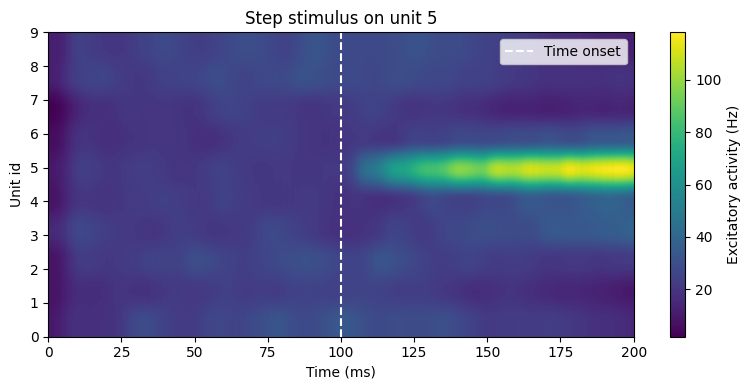

In [3]:
# Purpose:
# Initialize  and simulate the cortical field model for Exercise 3.1 with a step external stimulus, to
# finally plot the 2D excitatory activity map 

# Source of Code and Justification:
# Exercise 3.1 reuses the same coupled field model as Exercise 2.4 : multiple E-I units connected through 
# the population-level matrix W_unit. It also asks for applying a step input to the excitatory population 
# of unit 5 for I_ext,E(t) = I0, for t >= 100 ms, with I0 = 30 nA, T = 200 ms, and W0 = 45 pC. The unit-unit 
# input is still computed as in Exercise 2.4 : I_unit = W_unit @ r_delayed. It finally asks for the same type 
# of plot as Exercise 2.4.

# Approach:
# - Generate W_unit using generate_unit_connectivity with W0 = 45 pC.
# - Create one independent EIUnit per spatial location and store them in a list as before.
# - Build delayed population activity vector [r_E, r_I] with synaptic delay and compute spatial coupling 
#   through W_unit @ r_delayed.
# - Add the step stimulus to I_E_units[stim_exc_unit] when t >= time_onset_ms.
# - Convert population activity from 1/ms to Hz (multiply by 1000) and plot a space-time heatmap.

# What to say in Report:
# "We initialized 10 coupled E-I units through connectivity matrix W on a ring with independent sparse 
# recurrent E/I network. The coupling strength was set to W0 = 45 pC, below the spontaneous bump threshold 
# found in Exercise 2.5. Starting at t = 100 ms, an additional constant external current I0 = 30 nA was applied 
# only to the excitatory population of unit 5. The excitatory activity was visualized as a space-time heatmap. 
# After stimulus onset at t = 100 ms, activity increased around the stimulated unit and propagated to 
# neighboring units."


W_unit, x = generate_unit_connectivity(Nunits, sigma, W0, g, gamma)
seed = 99
units = []

for unit_id in range(Nunits):

    W_recurrent = generate_sparse_connectivity(
        NE=NE,
        NI=NI,
        KE=KE,
        KI=KI,
        J=J,
        g=g,
        seed=seed + unit_id,
    )

    unit = EIUnit(
        W=W_recurrent,
        NE=NE,
        dt=dt,
        tau_m=tau_m,
        R=R,
        theta=theta,
        u_reset=u_reset,
        tau_delay_ms=tau_delay,
        n_bg=n_bg,
        bg_scale=bg_scale,
        rng=np.random.default_rng(seed + 1000 + unit_id),
    )
    units.append(unit)


print(f"Initialized {len(units)} E-I units.")
print("W_unit shape:", W_unit.shape)
print(f"I0 = {I0} nA, sigma = {sigma}, W0 = {W0} pC")


delay_steps = int(round(tau_delay / dt))
alpha_rate = 0.98

r_E = np.zeros((n_steps, Nunits), dtype=float)
r_I = np.zeros((n_steps, Nunits), dtype=float)

for k in range(n_steps):

    if k >= delay_steps:
        delayed_activity = np.concatenate([
            r_E[k - delay_steps],
            r_I[k - delay_steps],
        ])

    else:
        delayed_activity = np.zeros(2 * Nunits, dtype=float)

    # Unit-level synaptic input (pC * 1/ms -> nA)
    I_unit = W_unit @ delayed_activity
    I_E_units = I_unit[:Nunits].copy()
    I_I_units = I_unit[Nunits:]

    if time_ms[k] >= time_onset_ms:
        I_E_units[stim_exc_unit] += I0
        
    for alpha, unit in enumerate(units):
        _, _, rE_alpha, rI_alpha = unit.step(
            I_E=I_E_units[alpha],
            I_I=I_I_units[alpha],
        )
        if k == 0:
            r_E[k, alpha] = rE_alpha
            r_I[k, alpha] = rI_alpha
        else:
            r_E[k, alpha] = (
                alpha_rate * r_E[k - 1, alpha]
                + (1.0 - alpha_rate) * rE_alpha
            )
            r_I[k, alpha] = (
                alpha_rate * r_I[k - 1, alpha]
                + (1.0 - alpha_rate) * rI_alpha
            )
            
print("Simulation complete.")

r_E_hz = 1000.0 * r_E

plt.figure(figsize=(8, 4))
plt.imshow(
    r_E_hz.T,
    aspect="auto",
    origin="lower",
    extent=[0, T_ms, 0, Nunits - 1],
)

plt.axvline(time_onset_ms, color="white", linestyle="--", linewidth=1.5, label="Time onset")
plt.colorbar(label="Excitatory activity (Hz)")
plt.xlabel("Time (ms)")
plt.ylabel("Unit id")
plt.title(f"Step stimulus on unit {stim_exc_unit}")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex3_1_step_stimulus_unit_5.png", dpi=300)
plt.show()

# 3.1.1 Results plot of a specific unit stimulus 

Before stimulus onset (t<100 ms), all excitatory populations show low, relatively uniform activity (roughly 10–30 Hz), with small fluctuations from stochastic background input. There is no localized bump and no unit dominates the network. At t=100 ms (step onset on unit 5), activity increases sharply on the stimulated unit: unit 5 reaches very high firing rates (on the order of >100 Hz in the heatmap). This localized high-activity band persists for the rest of the simulation.

# 3.1.2 What happens to the activity of the populations that are not directly stimulated ?

Neighboring units (e.g. units 4 and 6) show a moderate increase in excitatory activity after stimulus onset (intermediate colors, roughly 40–60 Hz). They are not driven directly by I0, but receive input through spatial coupling in W: short-range E→E excitation from unit 5 spreads activity to nearby locations on the ring. More distant units (e.g. units 0, 1, 8, 9) remain at low activity, similar to the pre-stimulus baseline. They are not stimulated directly, and the combination of long-range inhibition (distant E populations recruiting local I populations) and weaker long-range excitation prevents a global increase in activity. This is consistent with surround suppression: elevated activity near the stimulus and comparatively suppressed or unchanged activity farther away. So non-stimulated populations are not independent of the stimulus: nearby ones are facilitated by lateral excitation, while distant ones stay low because of long-range inhibitory effects mediated by the connectivity structure.

# 3.1.3 Why is it important that W0 is below the critical value described in Ex. 2.5 ?

In Exercise 2.5, spontaneous bump formation required approximately W0≳60 pC. Here we use W0=45 pC, which is below that threshold. That matters for two reasons.
First, no spontaneous attractor — With W0=45 pC, the network stays in a low-activity, spatially homogeneous state before the stimulus. The localized high-activity pattern after t=100 ms is therefore driven by the external step input, not by a self-sustained bump that would appear even without stimulation.
Second, cleaner interpretation of tuning — Exercises 3.2–3.3 measure responses to controlled stimuli (location, width). If W0 were above the critical value, a spontaneous bump could form and compete with or mask the stimulus-evoked pattern, making it hard to tell whether observed activity reflects the stimulus or intrinsic network dynamics.
In short : W0 < W0, critical keeps the network in a sub-threshold regime so that observed spatial patterns are stimulus-evoked, which is essential for studying paradoxical surround suppression in the following exercises.


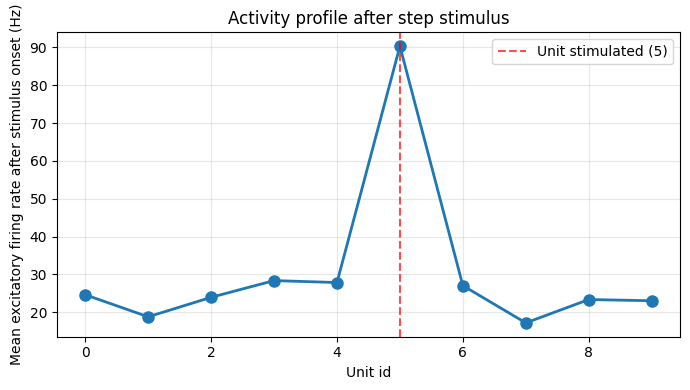

Unit 0 : mean excitatory rate = 24.64 Hz
Unit 1 : mean excitatory rate = 18.81 Hz
Unit 2 : mean excitatory rate = 23.95 Hz
Unit 3 : mean excitatory rate = 28.38 Hz
Unit 4 : mean excitatory rate = 27.86 Hz
Unit 5 : mean excitatory rate = 90.30 Hz
Unit 6 : mean excitatory rate = 27.04 Hz
Unit 7 : mean excitatory rate = 17.20 Hz
Unit 8 : mean excitatory rate = 23.37 Hz
Unit 9 : mean excitatory rate = 23.04 Hz


In [4]:
# Purpose:
# Compute and plot the mean excitatory activity after stimulus onset applied in ex 3.1.

# Source of Code and Justification:
# Exercise 3.2 asks for the mean excitatory activity after stimulus onset as a function of unit 
# location, using the simulation from Exercise 3.1. The stimulus was applied at t = 100 ms to unit 
# stim_exc_unit (5), so we average r_E only over t >= time_onset_ms.

# Approach:
# - Select the post-stimulus time window [time_onset_ms, T_ms].
# - For each unit, compute the mean excitatory activity (in Hz) over that window.
# - Plot mean activity versus unit id.

# What to say in Report:
# "After stimulus onset, we averaged the excitatory population activity of each unit over
# the interval t >= 100 ms. The resulting profile gave a peak at the stimulated unit and
# was decayed with distance along the ring (other units), reflecting short-range excitation 
# and long-range inhibition."


# Time indices after the stimulus onset
after_onset_idx = time_ms >= time_onset_ms

# Mean excitatory activity per unit (Hz) after stimulus onset
mean_rate_E_hz_after = r_E_hz[after_onset_idx, :].mean(axis=0)

unit_ids = np.arange(Nunits)

plt.figure(figsize=(7, 4))
plt.plot(unit_ids, mean_rate_E_hz_after, "o-", linewidth=2, markersize=8)
plt.axvline(stim_exc_unit, color="red", linestyle="--", alpha=0.7,
            label=f"Unit stimulated ({stim_exc_unit})")
plt.xlabel("Unit id")
plt.ylabel("Mean excitatory firing rate after stimulus onset (Hz)")
plt.title("Activity profile after step stimulus")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex3_2_mean_firing_activity_vs_unit.png", dpi=300)
plt.show()

for i in range(Nunits):
    print(f"Unit {i} : mean excitatory rate = {mean_rate_E_hz_after[i]:.2f} Hz")

# 3.2 Tuning curve interpretation 


After averaging excitatory activity for t > 100 ms, the network shows a localized peak at unit 5 (the directly stimulated population). Neighboring units (4 and 6) display intermediate mean activity, while more distant units remain at lower levels. This reflects the connectivity structure: short-range E→E coupling spreads activity locally, whereas long-range E→I coupling suppresses activity in units far from the stimulus.

The ring has periodic boundary condition and spatially symmetric connectivity : each unit has the same internal E/I network, and W depends only on the distance d(x_alpha, x_beta) between positions, not on absolute location.

Therefore, stimulating unit (alpha) and measuring activity at all units is equivalent to fixing the recording unit (e.g. unit 5) and moving the stimulus to different locations on the ring. Because of this radial symmetry, the x-axis can be reinterpreted as unit location (where we measure activity), when the stimulus is fixed at one unit, or as stimulus location (where we apply the input), when the recorded unit is fixed.

In both views, the same bell-shaped profile is obtained : maximum response when the stimulus is centered on the recorded population, with decreasing response as stimulus distance increases. This is the definition of a spatial tuning curve for stimulus position.


Unit investigated : 5
List sigma values : [0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4 ]
Record interval : [50.0, 200.0] ms


sigma_stim sweep: 100%|██████████| 11/11 [00:08<00:00,  1.26it/s]


Done.
sigma = 0.00 -> mean excitatory rate = 123.39 Hz
sigma = 0.04 -> mean excitatory rate = 125.86 Hz
sigma = 0.08 -> mean excitatory rate = 136.00 Hz
sigma = 0.12 -> mean excitatory rate = 141.13 Hz
sigma = 0.16 -> mean excitatory rate = 139.68 Hz
sigma = 0.20 -> mean excitatory rate = 138.49 Hz
sigma = 0.24 -> mean excitatory rate = 135.16 Hz
sigma = 0.28 -> mean excitatory rate = 127.55 Hz
sigma = 0.32 -> mean excitatory rate = 120.25 Hz
sigma = 0.36 -> mean excitatory rate = 116.05 Hz
sigma = 0.40 -> mean excitatory rate = 113.05 Hz


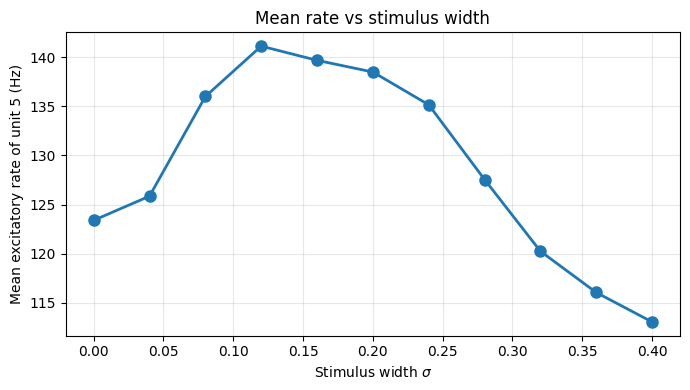

In [5]:
# Purpose:
# Define parameters for the stimulus width, run the cortical field simulation for each stimulus width 
# and record the mean excitatory firing rate of the investigated unit, and finally plot the tuning curve : 
# mean excitatory rate vs stimulus width.

# Source of Code and Justification:
# Exercise 3.3 applies a gaussian external stimulus (Eq. 13) centered on one E-I unit. The stimulus 
# width sigma is varied from 0 to 0.4 in steps of 0.04. The firing rate is computed over the last 150 ms.
# W0 = 45 pC keeps the network below spontaneous bump formation.
# Eq. (13): I_ext,E_alpha = I0 * exp(-d(x_alpha,x0)^2/(2*sigma^2)) with x0 at the unit investigated. 
# For sigma = 0, the unit receives I0. Then Ex 3.3 asks for the mean firing rate of the unit investigated 
# as a function of sigma.

# Approach:
# - Fix the unit investigated and its ring position x0.
# - Define the range of sigma values.
# - Define the analysis interval [T_ms - 150, T_ms].
# - For each sigma, build a static Gaussian stimulus profile.
# - Reinitialize W_unit and all EI Units.
# - Simulate T = 200 ms with constant external stimulus from t = 0.
# - Average excitatory firing rate of unit_investigated over the last 150 ms and convert to Hz.
# - Plot mean_rate_unit_investigated versus sigma_values.

# What to say in Report:
# "We measured how the mean excitatory firing rate of one unit depended on stimulus width. The 
# Gaussian stimulus was always centered on that unit, with I0 = 30 nA and W0 = 45 pC. For each stimulus 
# width, we ran a 200 ms simulation with a Gaussian input centered on unit 5. The mean excitatory rate 
# of unit 5 was averaged over the final 150 ms. The tuning curve wasn't monotonic : firing rate first
# increased with stimulus width, then decreased beyond a critical sigma."



# Unit we measure + center of stimulus
unit_investigated = 5

# Varying sigma : 0 (= single unit) to 0.4 in steps of 0.04, we include 0.4 by adding half step size
sigma_values = np.arange(0.0, 0.4 + 0.04 / 2, 0.04)

# record interval
record_start_ms = T_ms - 150.0   # 50 ms
record_end_ms = T_ms             # 200 ms

print(f"Unit investigated : {unit_investigated}")
print(f"List sigma values : {sigma_values}")
print(f"Record interval : [{record_start_ms}, {record_end_ms}] ms")

W_unit, x = generate_unit_connectivity(Nunits, sigma, W0, g, gamma)
x0 = x[unit_investigated]
mean_rate_unit_investigated = []

for sigma in tqdm(sigma_values, desc="sigma_stim sweep"):
    if sigma == 0.0:
        I_E_stimulated = np.zeros(Nunits, dtype=float)
        I_E_stimulated[unit_investigated] = I0
    else:
        d = np.array([ring_distance(x[alpha], x0) for alpha in range(Nunits)])
        I_E_stimulated = I0 * np.exp(-(d**2)/(2.0*sigma**2))
    units = []

    for unit_id in range(Nunits):
        W_recurrent = generate_sparse_connectivity(NE=NE, NI=NI, KE=KE, KI=KI, J=J, g=g,
            seed=seed + 3456 + int(round(sigma*1000)) + unit_id,)
        unit = EIUnit(
            W=W_recurrent,
            NE=NE,
            dt=dt,
            tau_m=tau_m,
            R=R,
            theta=theta,
            u_reset=u_reset,
            tau_delay_ms=tau_delay,
            n_bg=n_bg,
            bg_scale=bg_scale,
            rng=np.random.default_rng(seed + 4567 + int(round(sigma*1000)) + unit_id),
        )
        units.append(unit)

    r_E = np.zeros((n_steps, Nunits), dtype=float)
    r_I = np.zeros((n_steps, Nunits), dtype=float)

    for k in range(n_steps):
        if k >= delay_steps:
            delayed_activity = np.concatenate([r_E[k - delay_steps], r_I[k - delay_steps],])
        else:
            delayed_activity = np.zeros(2 * Nunits, dtype=float)
        I_unit = W_unit @ delayed_activity
        I_E_units = I_unit[:Nunits].copy() + I_E_stimulated   # Eq. (13) + spatial coupling
        I_I_units = I_unit[Nunits:]
        for alpha, unit in enumerate(units):
            _, _, rE_alpha, rI_alpha = unit.step(I_E=I_E_units[alpha], I_I=I_I_units[alpha])
            if k == 0:
                r_E[k, alpha] = rE_alpha
                r_I[k, alpha] = rI_alpha
            else:
                r_E[k, alpha] = (alpha_rate * r_E[k - 1, alpha]+ (1.0 - alpha_rate) * rE_alpha)
                r_I[k, alpha] = (alpha_rate * r_I[k - 1, alpha]+ (1.0 - alpha_rate) * rI_alpha)

    # Mean rate of recorded unit over last 150 ms (Hz)
    mask_time = (time_ms >= record_start_ms) & (time_ms <= record_end_ms)
    mean_rate_hz = 1000.0 * r_E[mask_time, unit_investigated].mean()
    mean_rate_unit_investigated.append(mean_rate_hz)

mean_rate_unit_investigated = np.array(mean_rate_unit_investigated)
print("Done.")
for s, r in zip(sigma_values, mean_rate_unit_investigated):
    print(f"sigma = {s:.2f} -> mean excitatory rate = {r:.2f} Hz")


plt.figure(figsize=(7, 4))
plt.plot(sigma_values, mean_rate_unit_investigated, "o-", linewidth=2, markersize=8)
plt.xlabel(r"Stimulus width $\sigma$")
plt.ylabel(f"Mean excitatory rate of unit {unit_investigated} (Hz)")
plt.title("Mean rate vs stimulus width")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex3_3_mean_rate_vs_sigma.png", dpi=300)
plt.show()


# 3.4.1 How can the mean firing rate decrease when stimulus width increases ?

When the stimulus is narrow and centered on a unit, only nearby excitatory populations receive strong external input; they reinforce one another through short-range WE←E coupling (d≤σ), so activity at the center increases. As σstim grows, many more units along the ring are stimulated. Those distant units do not provide strong local excitation to the center, but they recruit inhibitory populations through long-range WI←E coupling (d>σ), increasing inhibition in a broad surround. When that surround inhibition outweighs the benefit of wider direct excitation at the center, the net drive to the recorded excitatory population falls and the mean firing rate decreases—even though the stimulus covers a larger area. This is surround suppression: a wider stimulus activates inhibition more than useful excitation at the center. 

# 3.4.2 Relation between σ_stim and connectivity parameters 

The σ_stim at which the rate begins to fall is set mainly by the spatial scale σ in the unit–unit connectivity matrix, which separates short-range excitation from long-range inhibition on the ring. While σ_stim ≲ σ, the stimulus stays within the local excitatory neighborhood and the rate typically rises; when σstim exceeds σ, the stimulus drives distant units that mainly contribute surround inhibition, so the tuning curve turns down (the peak often lies near σ_stim ∼ σ–2σ, e.g. order 0.1–0.2 for σ=0.2). This transition is modulated by W0 (overall coupling strength) and by g and γ (inhibitory efficacy via WI←E = gγW0): stronger inhibition or coupling makes the decrease appear at smaller σ_stim. 


# 3.5.1 Cause for decreased firing rate

In our model, the direct cause of the decreased excitatory firing rate for wide stimuli is increased inhibition, not decreased excitation at the center. The external excitatory current at the recorded location remains at I0; widening σstim mainly recruits activity in distant excitatory populations, which drive inhibitory populations through long-range WI←E coupling. That raises net inhibitory input to the central excitatory population and lowers rE via recurrent E–I dynamics—surround suppression mediated by inhibition. 

# 3.5.2 Underlying mechanism relating to inhibition-dominated state 

If only that direct cause were measurable experimentally (e.g. stronger inhibitory responses for large stimuli), one would infer an inhibitory surround mechanism rather than reduced excitatory drive at the center, but could not identify the exact circuit without further measurements. This aligns with the inhibition-dominated state from Exercise 1: with large g and γ, recurrent inhibition (gγrI) stabilizes excitation; a wide stimulus increases rI network-wide and shifts the center toward a regime where inhibition dominates net synaptic input—consistent with balanced, inhibition-stabilized cortical dynamics. 
